In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('../data/processed/uber.csv')

In [16]:
pd.set_option('display.max_column', None)

In [17]:
df['full_time'] = pd.to_datetime(df['full_time'])

df['date'] = pd.to_datetime(df['date'])

## What is the daily/weekly/monthly ride volume trend?

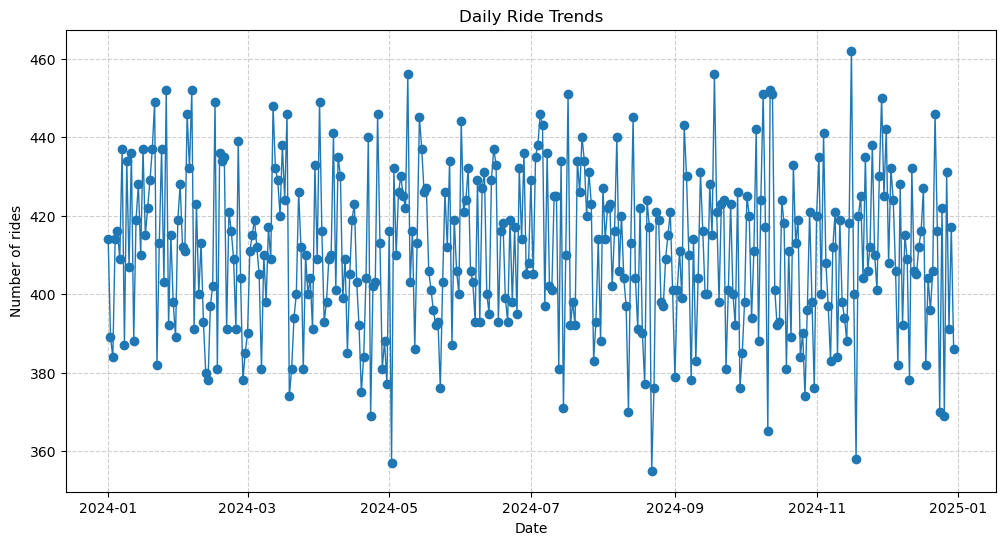

In [19]:
# daily trends

daily_trend = df.groupby('date')['booking_id'].count().reset_index(name='ride_count')

plt.figure(figsize=(12,6))
plt.plot(daily_trend['date'], daily_trend['ride_count'], marker='o', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Number of rides')
plt.title('Daily Ride Trends')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [20]:
# weekly

weeks = df['date'].dt.isocalendar().week
weekly_trend = df.groupby(weeks)['booking_id'].count().reset_index(name='weekly_trend')

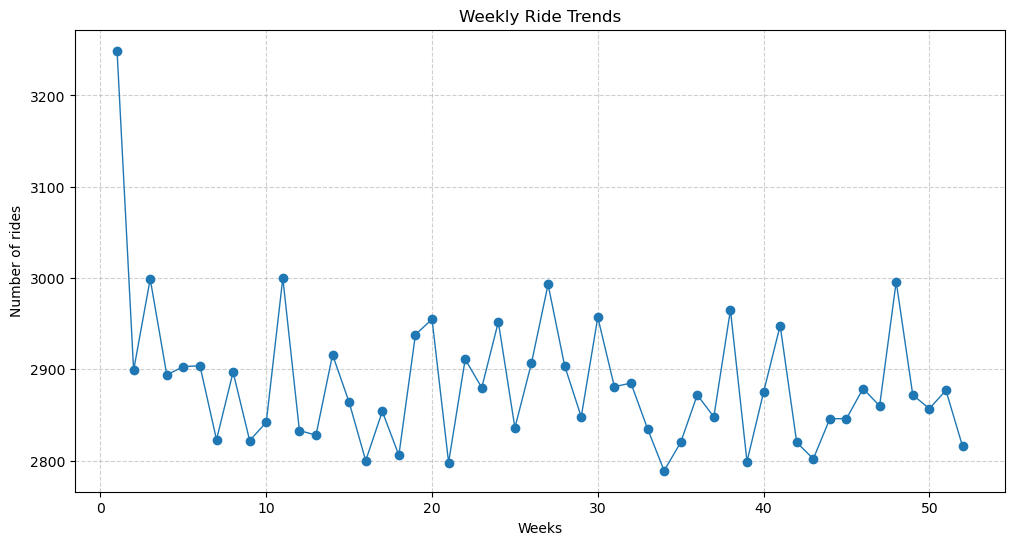

In [21]:
plt.figure(figsize=(12,6))
plt.plot(weekly_trend['week'], weekly_trend['weekly_trend'], marker='o', linewidth=1)

plt.xlabel('Weeks')
plt.ylabel('Number of rides')
plt.title('Weekly Ride Trends')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [22]:
# monthly

months = df['date'].dt.month
monthly_rides = df.groupby(months)['booking_id'].count().reset_index(name='monthly_rides')

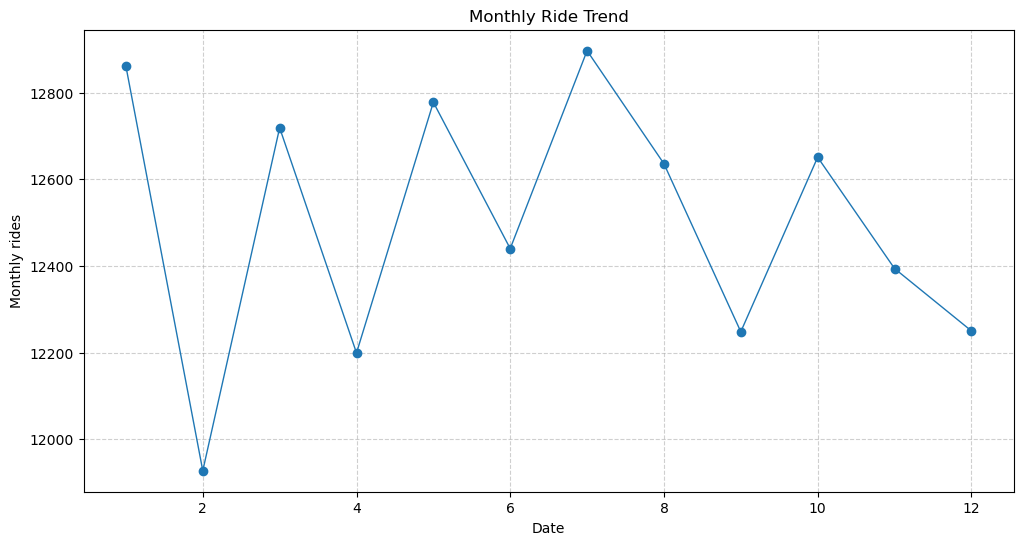

In [23]:
plt.figure(figsize=(12,6))
plt.plot(monthly_rides['date'], monthly_rides['monthly_rides'], marker='o', linewidth=1)
plt.title('Monthly Ride Trend')
plt.xlabel('Date')
plt.ylabel('Monthly rides')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## What are the busiest hours of the day for Uber rides?

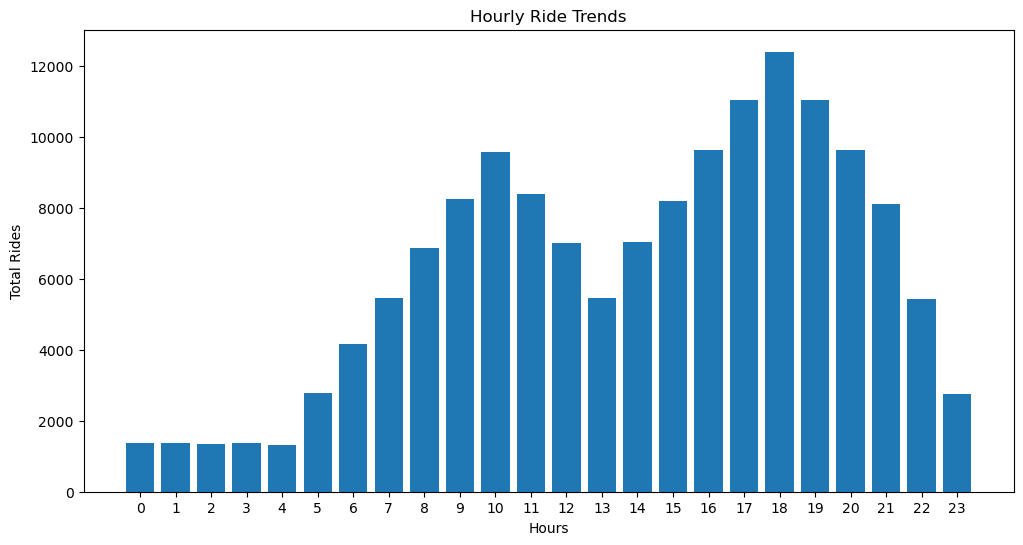

In [25]:
hours = df['full_time'].dt.hour

hourly_ride = df.groupby(hours)['booking_id'].count().reset_index(name='hourly_rides')

plt.figure(figsize=(12,6))
plt.bar(hourly_ride.index, hourly_ride['hourly_rides'])
plt.xticks(hourly_ride.index)
plt.xlabel('Hours')
plt.ylabel('Total Rides')
plt.title('Hourly Ride Trends')

plt.show()

## Which pickup and drop locations are most frequent?

In [27]:
pickup_location = df.pickup_location.value_counts().sort_values(ascending=False).head(1).reset_index()
drop_location = df.drop_location.value_counts().sort_values(ascending=False).head(1).reset_index()

result = pd.concat([pickup_location, drop_location])
result

,pickup_location,count,drop_location
0,Khandsa,949,NaN
0,NaN,936,Ashram


## What types of vehicles (vehicle_type) are most commonly booked?

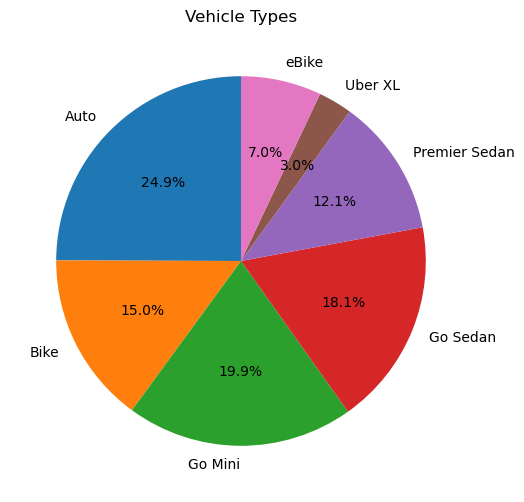

In [29]:
v_type = df.groupby('vehicle_type')['booking_id'].count().reset_index(name='bookings')

plt.figure(figsize=(10,6))
plt.pie(v_type['bookings'], labels=v_type['vehicle_type'], autopct='%1.1f%%', startangle=90)

plt.title('Vehicle Types')
plt.show()